## Tranco EDA
Exploratory data analysis on the Tranco Top 1M legitimate domain dataset.

**Dataset:** `/data/raw/top-1m.csv`
**List ID:** 6GPNX
**Date accessed:** 03/05/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/top-1m.csv', header=None, names=['rank', 'domain'])
df.head()

,rank,domain
0,1,google.com
1,2,microsoft.com
2,3,gtld-servers.net
3,4,facebook.com
4,5,mail.ru


In [8]:
df.shape


(1000000, 2)

In [7]:
df.dtypes

rank      int64
domain      str
dtype: object

## Null / Missing Value Analysis

In [10]:
df.isnull().sum()

(df == '').sum()

rank      0
domain    0
dtype: int64

## Duplicate Check

In [12]:
duplicateDomains = df["domain"].duplicated().sum()
duplicateRanks = df["rank"].duplicated().sum()
print(f'Duplicate domains: {duplicateDomains}')
print(f'Duplicate ranks: {duplicateRanks}')

Duplicate domains: 0
Duplicate ranks: 0


## TLD Distribution

In [4]:
df['tld'] = df['domain'].str.split('.').str[-1]
tld_counts = df['tld'].value_counts().head(15)
print(tld_counts)

tld
com    431460
net     51741
ru      42879
org     39514
de      26817
uk      22815
br      17524
jp      16280
in      12403
fr      11433
io      10800
nl      10241
it      10051
xyz      9407
pl       9054
Name: count, dtype: int64


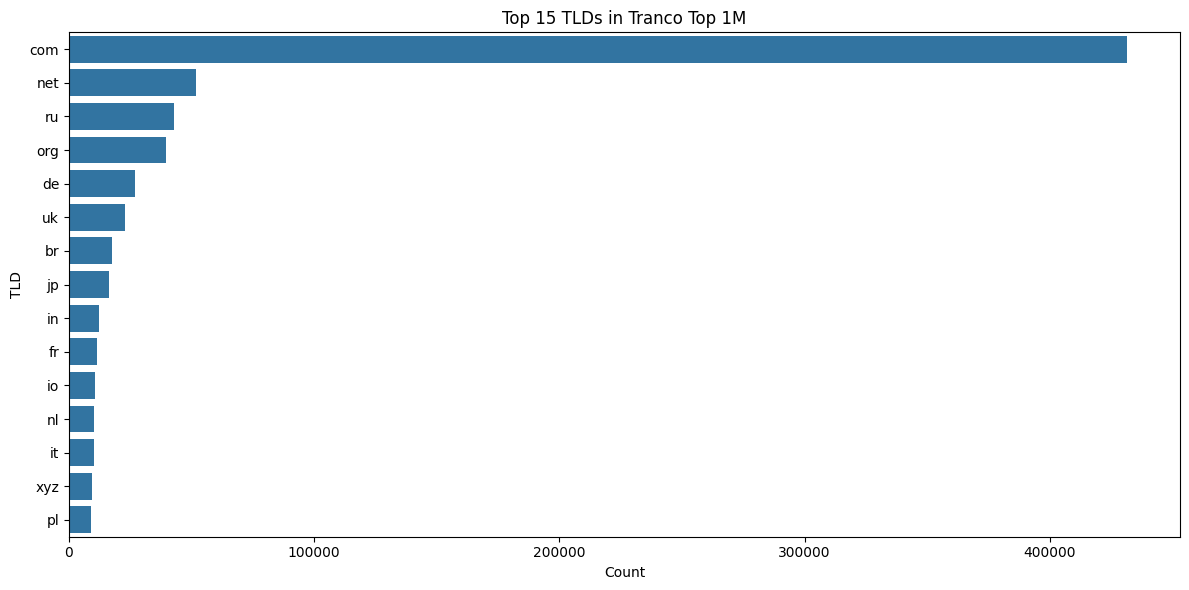

In [5]:
plt.figure(figsize=(12,6))
sns.barplot(x=tld_counts.values, y=tld_counts.index)
plt.title('Top 15 TLDs in Tranco Top 1M')
plt.xlabel('Count')
plt.ylabel('TLD')
plt.tight_layout()
plt.show()

## Domain Length Distribution


In [9]:
df['domain_length'] = df['domain'].str.len()
print(df['domain_length'].describe())

count    1000000.000000
mean          13.739423
std            4.346079
min            4.000000
25%           11.000000
50%           13.000000
75%           16.000000
max           75.000000
Name: domain_length, dtype: float64


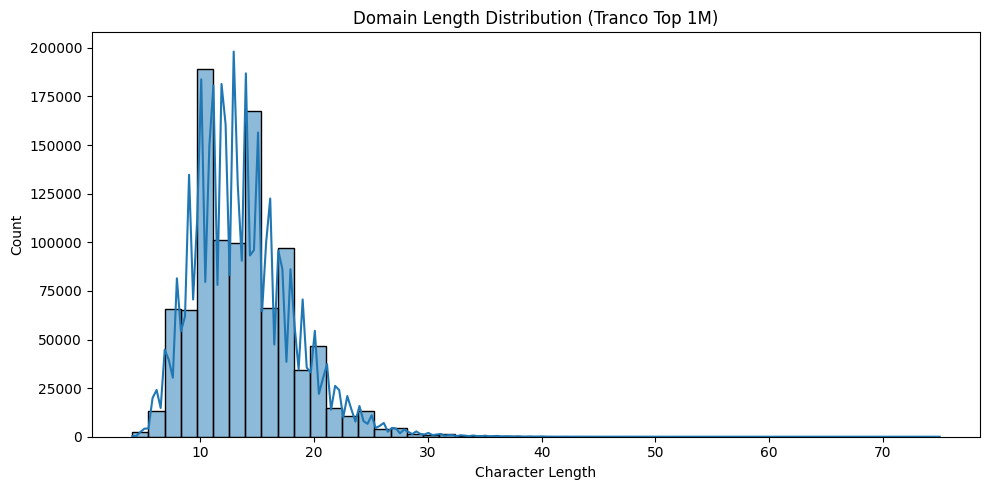

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['domain_length'], bins=50, kde=True)
plt.title('Domain Length Distribution (Tranco Top 1M)')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## PhishTank Overlap Analysis

In [17]:
from urllib.parse import urlparse

phish = pd.read_csv('../data/processed/phishtank_cleaned.csv')
phish['domain'] = phish['url'].apply(lambda x:
urlparse(x).netloc.lower().replace('www.', '', 1))

tranco_domains = set(df['domain'].str.lower())
overlap = phish['domain'].isin(tranco_domains).sum()
print(f'Phishing URLs whose domain appears in Tranco Top 1M: {overlap} /{len(phish)} ({overlap/len(phish)*100:.2f}%)')



Phishing URLs whose domain appears in Tranco Top 1M: 13662 /56045 (24.38%)


In [23]:
print(f"Tranco: {len(df):,} legitimate domains (ranked by popularity)")          
print(f"PhishTank: {len(phish):,} verified phishing URLs")
print(f"Overlap: {overlap:,} phishing domains found in Tranco top 1M({overlap/len(phish)*100:.2f}%)")
print()
print("Notes:")
print("- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe")
print("- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive")
print("- Overlap may reflect compromised legitimate domains or shared hosting infrastructure")




Tranco: 1,000,000 legitimate domains (ranked by popularity)
PhishTank: 56,045 verified phishing URLs
Overlap: 13,662 phishing domains found in Tranco top 1M(24.38%)

Notes:
- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe
- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive
- Overlap may reflect compromised legitimate domains or shared hosting infrastructure


## Export Cleaned Dataset


In [24]:
df.to_csv('../data/processed/tranco_cleaned.csv', index=False)
print("Success.")

Success.
